# Landing Rating System


## Imports: libraries, Runways Database

In [17]:
import os
import json
from pathlib import Path
import tomllib

# Dataframe and Mathematical Toolbox
import pandas as pd
import numpy as np
import datetime as dt
from scipy.signal import find_peaks

# Visualization Packages
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import seaborn as sns

import src.geographic_calculations as gc
import src.parsing_handler as ph
from importlib import reload
reload(gc)
reload(ph)

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 20)
pd.set_option('display.max_rows', 120)

# Load the configuration file
config_path = Path("CONFIG_HERE.toml")
with config_path.open('rb') as f:
    config = tomllib.load(f)

input_path = Path(config['input']['csv_path'])
THRESHOLDS_DB_PATH = config["default_paths"]["THRESHOLDS_DB_PATH"]
# Tacview Data Parameter
sampling_rate = config["input"]["sampling_rate"] # Hz

In [2]:
# load airport threshold db
def load_runway_db(db_path: str):
    '''Loads the runway threshold database from a JSON file.'''
    
    db_path = Path(db_path)

    with db_path.open("r", encoding="utf-8") as f:
        runway_db = json.load(f)

    if not runway_db:
        raise ValueError(f"Runway DB is empty: {db_path}")

    return runway_db

runway_db = load_runway_db(THRESHOLDS_DB_PATH)

## Tacview csv flight data

In [18]:
# Read csv input
df = pd.read_csv(input_path)
# Get date from tacview file
date_tacview = pd.to_datetime(df.loc[0,'ISO time'], errors='coerce').\
                strftime('%Y.%m.%d').replace('.','')
date_tacview = f"[{date_tacview}]"

# Output Path
results_dir = fr'..\Landing Rating\Results\[{date_tacview}] Checkride 1'
os.makedirs(results_dir, exist_ok=True)
os.makedirs(results_dir+'\\Detailed Touchdowns', exist_ok=True)

print(df.shape)
print(f"date_tacview: {date_tacview}")
df.head(2)

(66206, 17)
date_tacview: [20200531]


,ISO time,Unix time,Id,Longitude,Latitude,Altitude,Roll,Pitch,Yaw,U,V,Heading,Name,Pilot,CAS,AGL,VS
0,2020-05-31T20:41...,1.590958e+09,103,144.918735,13.586413,159.48,-0.3,0.7,155.9,13220.07,11107.55,156.4,F-16C_50,< 404C > Phoenix,0.0,1.811874,-0.000107
1,2020-05-31T20:41...,1.590958e+09,103,144.918735,13.586413,159.48,-0.3,0.7,155.9,13220.07,11107.55,156.4,F-16C_50,< 404C > Phoenix,0.0,1.811859,-0.000107


## Filter to Pilots List

In [4]:
print( np.sort(df['Pilot'].unique().astype(str)) )

['< 404 > D1CE' '< 404C > Phoenix']


In [6]:
# Choose Pilots to be evaluated

Freelancers_Pilots = ['< 404C > Dragon 5',   '< 404C > F.U.B.A.R', '< 404C > IR.shadow', 
'< 404C > Ghost', '< 404C > Phoenix' ,   '< 404C > Sensei' , '< 404C > Rough14', 
'< 404C > Cooper', '< 404C > Persianoid' , '< 404C > LCDR vici' ,
'< 404 > ALPHA-WHISKEY', '< 404 > Aria', '< 404 > A D L E R',
'< 404 > D1CE', '< 404 > FanBoy', '< 404 > Hawk_7', 'HoneyBadger']
observed_Pilots = sorted(Freelancers_Pilots)

# Filter df to observed_Pilots
df = df[df['Pilot'].isin(observed_Pilots)]
print(np.sort(df['Pilot'].unique()))
print("Number of pilots:", len(df['Pilot'].unique()))

['< 404 > D1CE' '< 404C > Phoenix']
Number of pilots: 2


## `df_sub`: Unit Conversion & Clean-ups

- Subset df to `Pilot` + `CAS` + `AGL` + `VS` + `long` + `lat`
- Time Wrangling: Extracting timestamp minutes, seconds from `ISO time` column

In [7]:
df_sub = df[['ISO time', 'Name', 'Pilot', 'Longitude','Latitude', 'CAS', 'AGL', 'VS']]

# Unit Conversion
df_sub.loc[:, 'CAS'] = df_sub['CAS'] * 2       # convert CAS from unknown to kts
df_sub.loc[:, 'VS' ] = df_sub['VS' ] * 196.85  # convert VS from m/s to ft/min
df_sub.loc[:, 'AGL'] = df_sub['AGL'] * 3.28084 # convert AGL from m to ft

# Clean-up from NaN values for `VS`
df_sub = df_sub.dropna(axis=0, subset=['VS']) .reset_index(drop=True)
# ISO time to datetime object
ts = pd.to_datetime(df_sub['ISO time'], errors='coerce')
if ts.isna().any():
    raise CSVInputError("Some 'ISO time' values could not be parsed.")
df_sub.insert(0, 'timestamp', ts)
# Convert to seconds
df_sub.insert(1, 'timestamp_seconds', 
                    (df_sub['timestamp'] - df_sub['timestamp'].iloc[0]).\
                    dt.total_seconds()
            )
#drop the 'ISO time'
df_sub.drop(columns=['ISO time'], inplace=True)

# Data Sampling Rate
# sampling_rate = 10#int(1 / round(df_sub['timestamp_seconds'].diff().iloc[1],3)) # Hz
print(f'Data Sampling Rate: {sampling_rate} Hz')

df_sub.head(3)

Data Sampling Rate: 10 Hz


,timestamp,timestamp_seconds,Name,Pilot,Longitude,Latitude,CAS,AGL,VS
0,2020-05-31 20:41:...,0.000000,F-16C_50,< 404C > Phoenix,144.918735,13.586413,0.0,5.94447,-0.021026
1,2020-05-31 20:41:...,0.100000,F-16C_50,< 404C > Phoenix,144.918735,13.586413,0.0,5.94442,-0.021026
2,2020-05-31 20:41:...,0.199999,F-16C_50,< 404C > Phoenix,144.918735,13.586413,0.0,5.94437,-0.021026


# Approach & Impact Analysis

## Vertical Speed, Acceleration, Jerk
- Right discrete derivative ${\frac{d^+}{dt}}VS \approx (VS_{t+1}-VS_{t-1})/2$
- Right discrete Jerk       ${\frac{d^{+2}}{dt^2}}VS \approx (VS'_{t+1}-VS'_{t-1})/2$
- <s> pct_chg of VS_chg_rate </s>

In [ ]:
# Time, AGL, VS increments
time_diff = df_sub.groupby('Pilot')['timestamp_seconds'].\
                                transform(lambda row: row.shift(-1) - row.shift(1))
VS_diff   = df_sub.groupby('Pilot')['VS']               .\
                                transform(lambda row: row.shift(-1) - row.shift(1))

# Vertical Acceleration (fpm2)
df_sub['vert_Acc_fpm2'] = (VS_diff / time_diff) * 60
# df_sub['vert_g'] = 1 + V^2/g.delta ; delta= gear strut

# Vertical Acc increments
vert_Acc_diff = df_sub.groupby('Pilot')['vert_Acc_fpm2'].\
                                transform(lambda row: row.shift(-1) - row.shift(1))             
# Vertical Jerk
df_sub['vert_Jerk_fpm3'] = (vert_Acc_diff / time_diff) * 60

## Impact Discovery

In [10]:
agl_threshold = 8  # feet
vs_threshold = -30  # feet per minute
aircraft_CG_height = {'F-16C_50': 6, 'F-15C': 6.5}
aircraft_stall_speed = {'F-16C_50': 110, 'F-15C': 110, 'FA-18C_hornet': 110}

# ------ CONDITIONS for TOUCHDOWN  for Each Pilot ------
grouped_by_pilot = df_sub.groupby('Pilot')

# Condition 1: AGL is a local minimum (current AGL is less than previous AND next)
is_decreasing_agl = (df_sub['AGL'] < grouped_by_pilot['AGL'].transform('shift', +1)) & \
                (df_sub['AGL'] < agl_threshold) & \
                (df_sub['AGL'] - grouped_by_pilot['AGL'].rolling(window=5*sampling_rate, 
                                                                center=True, 
                                                                min_periods=1).\
                                        min().reset_index(level=0, drop=True) < 3)  &\
                (grouped_by_pilot['AGL'].rolling(window=10*sampling_rate, min_periods=1).\
                                        max().reset_index(level=0, drop=True) > 20)
                # (df_sub['AGL'] < grouped_by_pilot['AGL'].transform('shift', +1)) 

# Condition 2: VS is below the threshold
is_low_vs = (df_sub['VS'] < vs_threshold) & (df_sub['VS'] > -2000) # Sanity Check

# Condition 3: CAS is above stall speed
is_above_stall = df_sub['CAS'] > df_sub['Name'].map(aircraft_stall_speed)

# Condition 4: Jerk is a "local" maximum
is_local_max_jerk = (df_sub['vert_Jerk_fpm3'] == (grouped_by_pilot['vert_Jerk_fpm3'].\
                                        rolling(window=1, center= True, min_periods=1).max().\
                                        reset_index(level=0, drop=True)).sort_index() )     & \
                        (df_sub['vert_Jerk_fpm3'] > 10000)                                                                    

# Condition 5: Vertical Acceleration becomes positive "in short time"
is_positive_acc = grouped_by_pilot['vert_Acc_fpm2'].\
                                rolling(window=int(0.5*sampling_rate), 
                                        center= False, 
                                        min_periods=1
                                        ).\
                                max().\
                                iloc[::-1].\
                                reset_index(level=0, drop=True).sort_index() > 0


# ------ TOUCHDOWN Candidates ------

# Combine all conditions into a single boolean mask
all_conditions_met = is_decreasing_agl & is_low_vs & is_above_stall & is_local_max_jerk & is_positive_acc
df_td_candidates = df_sub[all_conditions_met].copy()

# A "TRUE TOUCHDOWN" is a candidate where the time since the last one is > 5 seconds,
# or it's the very first one for that pilot (where time_since_last_td is NaN)
df_td_candidates['time_since_last_td'] = df_td_candidates.groupby('Pilot')['timestamp_seconds'].diff()

is_true_touchdown = (df_td_candidates['time_since_last_td'] > 5) | (df_td_candidates['time_since_last_td'].isna())
true_touchdown_indices = df_td_candidates[is_true_touchdown].index

# df_td_candidates[is_true_touchdown]

# --- Impact Analysis Result Back to df_sub ---
df_sub['is_touchdown'] = False
df_sub.loc[true_touchdown_indices, 'is_touchdown'] = True


###### Result Summary df_result ########

# Filter to touchdowns
df_result = df_sub[df_sub['is_touchdown']].drop(columns=[ 'is_touchdown']). \
                                                reset_index(drop=True)

# Rename col to td_col
df_result = df_result.rename(columns={ 'timestamp': 'td_timestamp',
                                        'timestamp_seconds': 'td_timestamp_seconds',
                                        'Latitude': 'td_latitude',
                                        'Longitude': 'td_longitude',
                                        'CAS': 'CAS_kt', 'AGL': 'AGL_ft', 'VS': 'VS_fpm'})

# Count sortie number if current touch is in less 10s from the previous touch
df_result.insert(0, 'sortie_num', df_result.groupby('Pilot').cumcount()+1)

time_diff = df_result.groupby('Pilot')['td_timestamp_seconds'].diff()
is_new_sortie = (time_diff >= 10) | (time_diff.isnull())
df_result.insert(0, 'real_sortie_num', is_new_sortie.groupby( df_result['Pilot'] ).cumsum())


In [11]:
# ------ Runway Detection ------
rwy_matches = df_result.apply(
                        lambda row: gc.find_closest_runway(
                                                        row["td_latitude"],
                                                        row["td_longitude"],
                                                        runway_db=runway_db,
                                                        ),
    axis=1,
)
rwy_matches_df = pd.DataFrame(rwy_matches.tolist(), index=df_result.index)

df_result["Airport"] = rwy_matches_df["airport_name"]
df_result["Runway"] = rwy_matches_df["runway"]
df_result["rwy_threshold_lat"] = rwy_matches_df["runway_coordinates"].str[0]
df_result["rwy_threshold_long"] = rwy_matches_df["runway_coordinates"].str[1]

df_result

,real_sortie_num,sortie_num,td_timestamp,td_timestamp_seconds,Name,Pilot,td_longitude,td_latitude,CAS_kt,AGL_ft,VS_fpm,vert_Acc_fpm2,vert_Jerk_fpm3,Airport,Runway,rwy_threshold_lat,rwy_threshold_long
0,1,1,2020-05-31 21:31:...,2993.697145,F-16C_50,< 404C > Phoenix,145.726434,15.117754,173.930893,4.474660,-501.793887,9742.375563,9.105286e+06,Saipan,07R,15.114576,145.718186
1,2,2,2020-05-31 22:22:...,6087.994194,F-16C_50,< 404C > Phoenix,144.924631,13.584309,172.038788,7.220391,-69.910946,1230.012131,1.564149e+06,Andersen,06L,13.580433,144.915826
2,1,1,2020-05-31 22:30:...,6530.193772,F-16C_50,< 404 > D1CE,144.919141,13.582125,173.448471,7.302242,-198.814415,1099.351501,1.825825e+06,Andersen,06L,13.580433,144.915826
3,3,3,2020-05-31 22:41:...,7190.493142,F-16C_50,< 404C > Phoenix,144.917117,13.580959,162.485626,7.312404,-190.040629,13731.981583,2.151845e+05,Andersen,06L,13.580433,144.915826
4,3,4,2020-05-31 22:41:...,7196.093137,F-16C_50,< 404C > Phoenix,144.920947,13.582630,157.029709,7.002723,-387.061839,886.690063,2.198343e+06,Andersen,06L,13.580433,144.915826


# Results

## Touchdown Ratings

In [ ]:
# Stylizing the Touchdowns Table
display_formatter = {'vert_Jerk_fpm3': '{:.2e}'}
for col in df_result.columns[df_result.columns.get_loc('CAS_kt'):df_result.columns.get_loc('vert_Acc_fpm2')+1]:
    display_formatter[col] = '{:.2f}'

# CSS Style for Result Table
styles_caption =    [   dict  ( selector='caption',
                                props=  [("text-align", "left"),
                                        ("font-size", "150%"),
                                        ("color", 'Black'),
                                        ("font-weight", "bold")  
                                        ]
                                )
                    ]
# style_table =   [dict  (selector="tbody tr:nth-child(even)",
#                         props=  [("background-color","#F5F5F5")]    )
#                 ] + \
style_table = [dict  (selector="table",
                        props = 'font-family: "Segoe UI", Tahoma, sans-serif; color: #e83e8c; font-size:1.3em;'    )
                ]
df_display = df_result.drop(columns=['td_timestamp_seconds', 'AGL_ft','vert_Acc_fpm2'])
styles_display = df_display.style.format(display_formatter).set_caption("All Touchdowns Result").\
                                                            set_table_styles(styles_caption+style_table). \
                                                            background_gradient(cmap='RdYlGn', 
                                                                gmap= df_display['VS_fpm'],
                                                                vmin= -450,
                                                                vmax= df_result['VS_fpm'].max(),
                                                                low=0.3, high=0.1
                                                                                ).\
                                                            background_gradient(cmap='Pastel1', subset=['sortie_num', 'real_sortie_num'], low=0.5, high=1)

display(styles_display)

# Export to csv
# df_result.drop(columns=['td_timestamp_seconds']).to_csv  (os.path.join(results_dir, f'{date_tacview}_landing_analysis_results.csv'), index=False)
# styles_display.to_html (os.path.join(results_dir, f'[{date_tacview}] landing_analysis_results.html'), index=False)

,real_sortie_num,sortie_num,td_timestamp,Name,Pilot,td_longitude,td_latitude,CAS_kt,VS_fpm,vert_Jerk_fpm3,Airport,Runway,rwy_threshold_lat,rwy_threshold_long
0,1,1,2020-05-31 21:31:12.297144+00:00,F-16C_50,< 404C > Phoenix,145.726434,15.117754,173.93,-501.79,9.11e+06,Saipan,07R,15.114576,145.718186
1,2,2,2020-05-31 22:22:46.594193+00:00,F-16C_50,< 404C > Phoenix,144.924631,13.584309,172.04,-69.91,1.56e+06,Andersen,06L,13.580433,144.915826
2,1,1,2020-05-31 22:30:08.793771+00:00,F-16C_50,< 404 > D1CE,144.919141,13.582125,173.45,-198.81,1.83e+06,Andersen,06L,13.580433,144.915826
3,3,3,2020-05-31 22:41:09.093141+00:00,F-16C_50,< 404C > Phoenix,144.917117,13.580959,162.49,-190.04,2.15e+05,Andersen,06L,13.580433,144.915826
4,3,4,2020-05-31 22:41:14.693136+00:00,F-16C_50,< 404C > Phoenix,144.920947,13.582630,157.03,-387.06,2.20e+06,Andersen,06L,13.580433,144.915826


# Visualizations

## Final Approach Profile

- *thresholds* $= \big( -\infty, x_{min} , \cdots, x_{max}, +\infty \big).$
- $(\text{strictness factor})*(\frac{x^k - x_{min}^k}{x_{max}^k - x_{min}^k})$ maps *thresholds* into $[0,1]$.

____________________

In [13]:
# ############## Descent Quality Labels and Colormaps ##############
# Select a colormap
cmap = plt.get_cmap('RdYlGn') 

# Create 'descent_rate' column
thresholds = [-np.inf, -1200, -800, -350, -300, -150, 0, np.inf]
min_thrshld = abs(sorted(thresholds)[1])   # worst VS threshold = 1200
max_thrshld = abs(sorted(thresholds)[-2])  # best  VS threshold = 150
num_categories = len(thresholds) - 1

labels = [f'$\leq$ {thresholds[1]}']
labels = labels + [f'[{thresholds[i]:<5g} , {thresholds[i+1]:5g}]' for i in range(1,len(thresholds)-2)]
labels.append(  f'$\geq 0$'  )

colors_list = [mcolors.to_hex(cmap( i**2 )) for i in np.linspace(0, 1, num_categories-1)]
colors_list.append(  '#000000'  )

color_map = dict(zip(labels, colors_list))

df_sub['descent_quality'] = pd.cut( df_sub ['VS'],
                                    bins=thresholds,
                                    labels=labels,
                                    include_lowest=True
                                )  # include_lowest is important for the bottom boundary

<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\g'
<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\g'
C:\Users\Fardad\AppData\Local\Temp\ipykernel_1356\1301685771.py:11: SyntaxWarning: invalid escape sequence '\l'
  labels = [f'$\leq$ {thresholds[1]}']
C:\Users\Fardad\AppData\Local\Temp\ipykernel_1356\1301685771.py:13: SyntaxWarning: invalid escape sequence '\g'
  labels.append(  f'$\geq 0$'  )


Sortie #4 of < 404C > Phoenix took less than 6 SECONDS!!


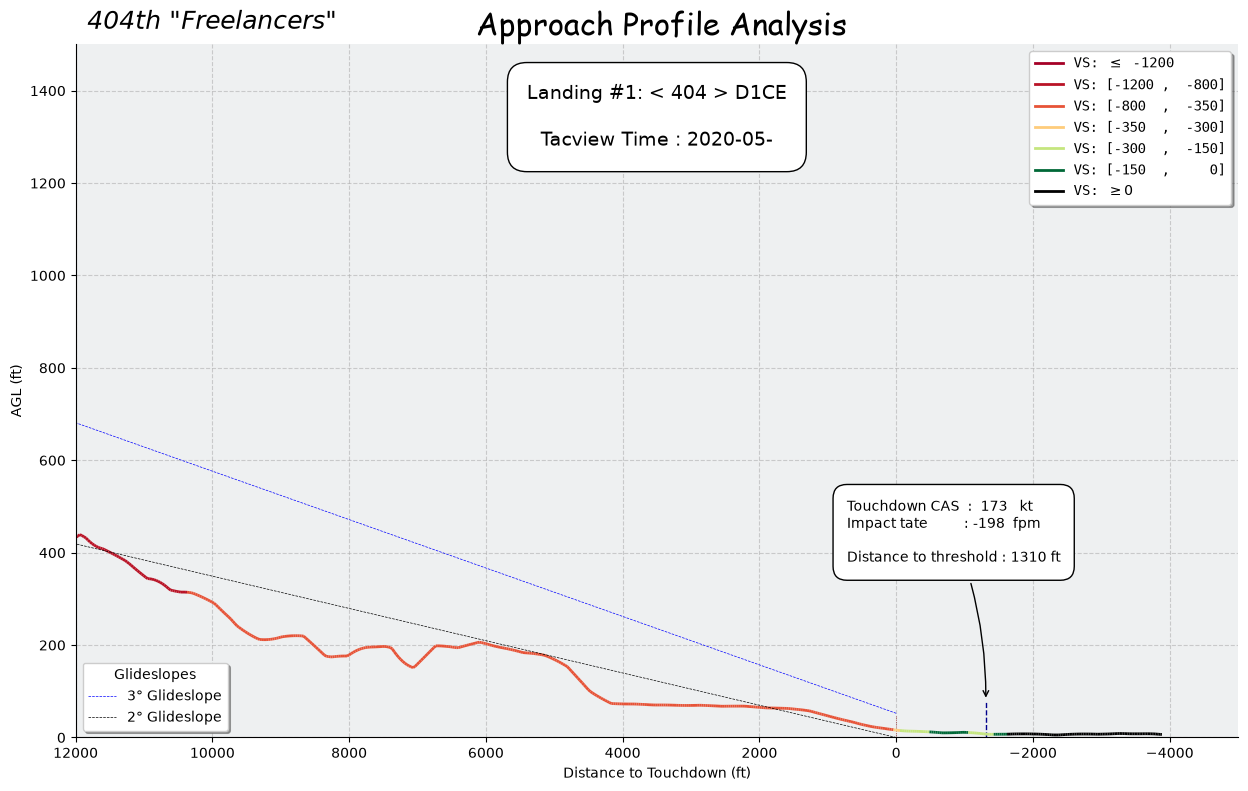

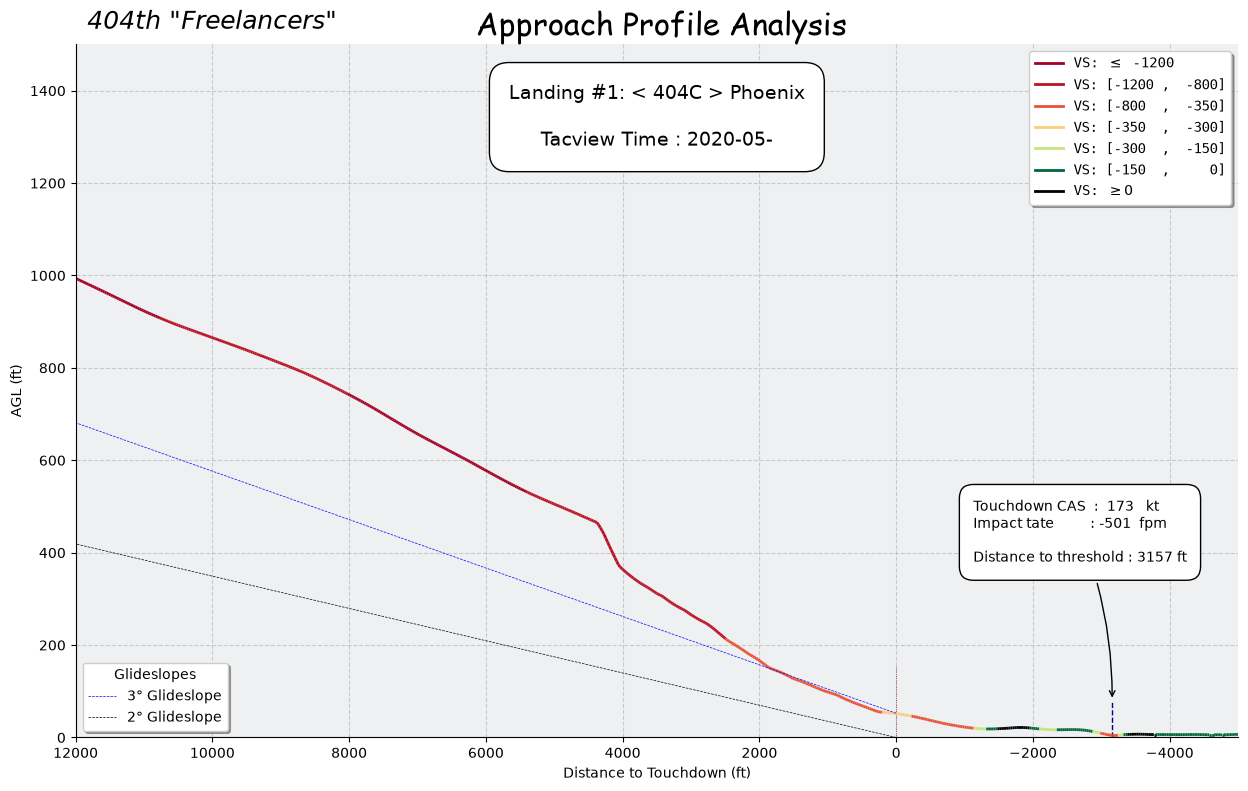

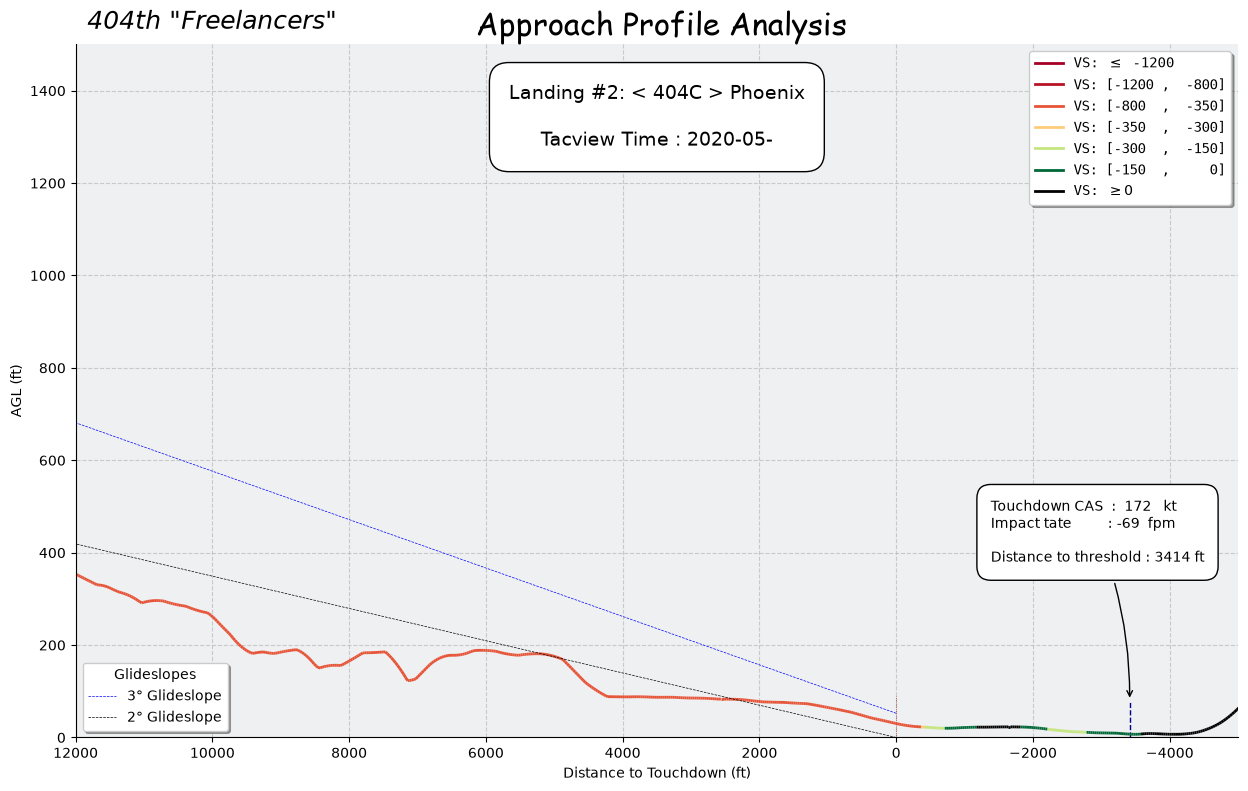

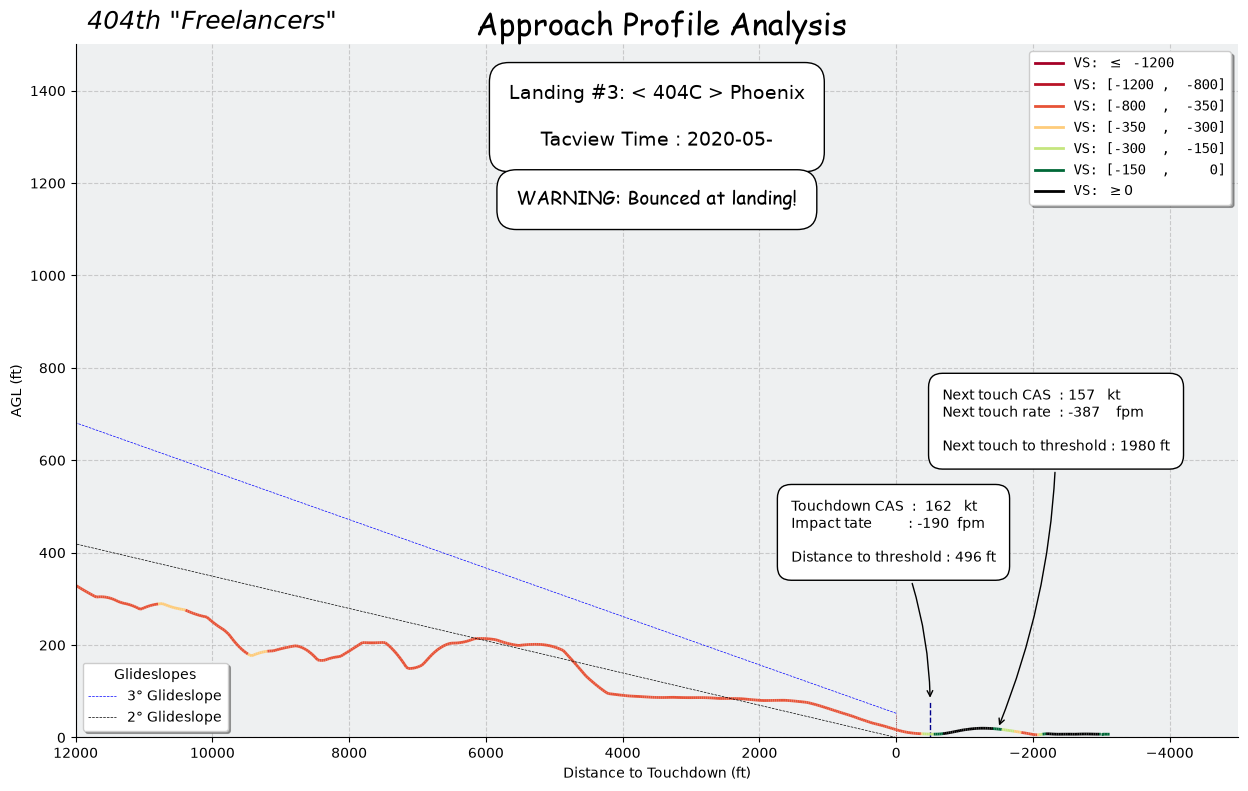

In [ ]:
# ###########################################################################################################################################
# ######################################################## Approach Plotter Function ########################################################

def approach_plotter(pilot, sortie_num):

  # Which part of final approach are we interested in?
  final_segment      = 60
  post_touch_segment = 10
    
  # Break if current touchdown is less than 5 second from the previous one
  current_touchdown  = df_result.loc[
                            (   (df_result['Pilot'] == pilot) & 
                                (df_result['sortie_num'] == sortie_num)
                            ), 
                            'td_timestamp_seconds'
                            ]
  previous_touchdown = df_result.loc[
                            (   (df_result['Pilot'] == pilot) & 
                                (df_result['sortie_num'] == sortie_num - 1)
                            ), 'td_timestamp_seconds'
                            ]
  next_touchdown     = df_result.loc[
                            (   (df_result['Pilot'] == pilot) & 
                                (df_result['sortie_num'] == sortie_num + 1)
                            ), 'td_timestamp_seconds'
                            ]
    
  # If there's no previous touchdown, we can't compare
  if not current_touchdown.empty and not previous_touchdown.empty:
    if current_touchdown.iloc[0] - previous_touchdown.iloc[0] < 6:
      print(f'Sortie #{sortie_num} of {pilot} took less than 6 SECONDS!!')
      return

  # --- Associate Every Data Point with its Upcoming Landing --- #
  # We keep the data 60s prior to touchdown and 20s after that
  df_forward = pd.merge_asof(
                          left=df_sub.loc[(df_sub['Pilot'] == pilot)].sort_values('timestamp_seconds'),
                          right=df_result.loc[
                                (df_result['Pilot'] == pilot) & (df_result['sortie_num'] == sortie_num) , 
                                ['sortie_num', 'Pilot', 'td_timestamp', 'td_timestamp_seconds', 'td_longitude', 'td_latitude']
                                ],
                          left_on='timestamp_seconds',
                          right_on='td_timestamp_seconds',
                          by='Pilot',
                          direction='forward',        # Look to prior to touchdown
                          tolerance= final_segment    # Only match if the touchdown is <= 60 seconds away
                          )
  df_backward = pd.merge_asof(
                          left=df_sub.loc[(df_sub['Pilot'] == pilot)].sort_values('timestamp_seconds'),
                          right=df_result.loc[
                                (df_result['Pilot'] == pilot) & (df_result['sortie_num'] == sortie_num) , 
                                ['sortie_num', 'Pilot', 'td_timestamp', 'td_timestamp_seconds', 'td_longitude', 'td_latitude']
                                ],
                          left_on='timestamp_seconds',
                          right_on='td_timestamp_seconds',
                          by='Pilot',
                          direction='backward',               # toward next sortie
                          tolerance= post_touch_segment,      # Only match if the touchdown is <= 20 seconds away
                          allow_exact_matches = False         # Touchdown entry itself is already included in df_forward
                          )
  # Only keeping entries upto 60s prior to touchdown or 10s after touchdown
  df_forward  = df_forward .dropna(subset=['td_latitude'])
  df_backward = df_backward.dropna(subset=['td_latitude'])

  # Calculate Distances prior to Touchdown
  df_forward['distance_to_touchdown'] = gc.haversine(
        df_forward['Latitude'].values, 
        df_forward['Longitude'].values, 
        df_forward['td_latitude'].values, 
        df_forward['td_longitude'].values
    )
  # Calculate Distances after Touchdown (negative direction)
  df_backward['distance_to_touchdown'] = - gc.haversine(
        df_backward['td_latitude'].values, 
        df_backward['td_longitude'].values, 
        df_backward['Latitude'].values, 
        df_backward['Longitude'].values
    )

  # following td columns should follow the same calculations as the flight prior to touchdown
  df_backward.rename(columns={'sortie_num'           : 'sortie_extended'               }, inplace=True)
  df_backward.rename(columns={'td_timestamp'         : 'td_timestamp_extended'         }, inplace=True)
  df_backward.rename(columns={'td_timestamp_seconds' : 'td_timestamp_seconds_extended' }, inplace=True)
  df_backward.rename(columns={'td_longitude'         : 'td_longitude_extended'         }, inplace=True)
  df_backward.rename(columns={'td_latitude'          : 'td_latitude_extended'          }, inplace=True)
  df_backward.rename(columns={'distance_to_touchdown': 'distance_to_touchdown_extended'}, inplace=True)

  # sortie to integer
  df_forward['sortie_num']  = df_forward ['sortie_num'].astype(int)
  df_backward['sortie_extended'] = df_backward['sortie_extended'].astype(int)

  # Merging: contains data 60s prior to touchdowns to 20 second after
  common_columns = list(set(df_forward.columns) & set(df_backward.columns))
  df_final_approach_merge = pd.merge(df_forward, 
                                    df_backward, 
                                    on=common_columns, 
                                    how='outer').sort_values(by='timestamp_seconds')

  # Filter for the current pilot and sortie number
  df_plot = df_final_approach_merge[ 
                                      (  df_final_approach_merge['Pilot'] == pilot) & \
                                      ( (df_final_approach_merge['sortie_num']        == sortie_num  ) + \
                                        (df_final_approach_merge['sortie_extended']   == sortie_num  )
                                      )
                                  ]

  df_plot['distance_to_touchdown_plot'] = np.where( df_plot['distance_to_touchdown_extended'].isnull(),
                                                    df_plot['distance_to_touchdown']                  ,
                                                    df_plot['distance_to_touchdown_extended']  
                                                  )
  # Ensure the DataFrame is not empty
  if df_plot.empty:
      print(f"No data available for {pilot} with sortie number {sortie_num}")
      return

  # PLOT SIZE + AXES LIMITS
  fig, ax = plt.subplots(figsize=(15, 9))
  ax.set_xlim(-5000, 12000)
  ax.set_ylim(0, 1500)

  # RWY Threshold Marking
  # The script calculates the distance from touchdown point (td_point). 
  # In order to zero it around the runway threshold (runway_threshold),
  # we need to shift all distances with dist_td_to_threshold.
  td_point = df_result.loc[
                              (df_result['Pilot'] == pilot) &\
                              (df_result['sortie_num'] == sortie_num ), 
                              ['td_longitude', 'td_latitude']
                            ].values[0]
  runway_threshold = df_result.loc[
                                    (df_result['Pilot'] == pilot) &\
                                    (df_result['sortie_num'] == sortie_num ), 
                                    ['rwy_threshold_lat', 'rwy_threshold_long']
                                    ].values[0]
  dist_td_to_threshold = gc.haversine(runway_threshold[1], runway_threshold[0], 
                                td_point[0], td_point[1]
                              )
  
  df_plot_sorted = df_plot.sort_values('distance_to_touchdown_plot')
  agl_at_threshold = np.interp(
                              dist_td_to_threshold, 
                              df_plot_sorted['distance_to_touchdown_plot'], 
                              df_plot_sorted['AGL']
                              )
  y_min, y_max = ax.get_ylim()
  relative_ymax = (agl_at_threshold - y_min) / (y_max - y_min)
  
  ax.axvline(x= 0, color='darkred', linestyle=':', linewidth=0.5, ymin=0, ymax=relative_ymax*3)
  ax.axvline(x= -dist_td_to_threshold, color='darkblue', linestyle='--', linewidth=1, ymin=0, ymax=80/y_max)

  # Map colors to descent_qualities
  colors = df_plot['descent_quality'].map(color_map, na_action=None)

  # Create segments for the LineCollection
  points = np.array(
                    [ df_plot['distance_to_touchdown_plot'] - dist_td_to_threshold, 
                      df_plot['AGL']
                    ]
              ).T.reshape(-1, 1, 2)
  segments = np.concatenate([points[:-1], points[1:]], axis=1)

  # Create a LineCollection object
  # The colors are applied to each segment
  lc = LineCollection(segments, colors=colors[:-1], linewidths=2)
  
  # PLOTTING    
  ax.add_collection(lc)
  ax.autoscale_view()
      

  # BACKGROUND GRAPHICS
  ax.grid(True, linestyle='--', alpha=0.6) # Added gridlines, adjusted alpha
  ax.set_facecolor("#EEF0F1FF")

  ax.invert_xaxis() # Invert x-axis to show glideslope

  # LABELS & TITLES
  ax.set_title(f' Approach Profile Analysis', fontsize=22, family='cursive')
  
  ax.text(0.01, 1.05, '404th "Freelancers"', transform=ax.transAxes, fontsize=18,
          fontstyle='italic', va='top', ha='left')#, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=1'))

  ax.text(np.mean(ax.get_xlim())*1, ax.get_ylim()[1]*0.9, 
          f'Landing #{sortie_num}: {df_plot["Pilot"].iloc[0]}\n\n'
          f"Tacview Time : {df_result [
                                      (df_result['Pilot'] == pilot) & (df_result['sortie_num'] == sortie_num)
                                      ]['td_timestamp'].astype(str).iloc[0][:8]}", 
          fontsize=14, ha='center', va= 'center_baseline', color='k',
          bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=1'))
  
  ax.set_ylabel('AGL (ft)')
  ax.set_xlabel('Distance to Threshold (ft)')

  # DESPINE
  sns.despine(ax=ax)

  # Create LEGEND
  color_map_last_segments = {k: color_map[k] for k in list(color_map.keys())[:]}
  legend_elements = [Line2D([0], [0], color=color, lw=2, label=f'VS: {label}')
                  for label, color in color_map_last_segments.items()]
  
  legend1 = ax.legend(handles=legend_elements, prop={'family': 'monospace', 'size': 10}, 
            bbox_to_anchor=(1., 1), loc='upper right', shadow=True)

  # ANNOTATIONS
  td_vs_fpm      = df_result[df_result['Pilot'] == pilot]['VS_fpm'].iloc[sortie_num-1]
  td_cas_kt      = df_result[df_result['Pilot'] == pilot]['CAS_kt'].iloc[sortie_num-1]

  # If there exist a next touchdown in less than 10s
  if not current_touchdown.empty and not next_touchdown.empty:
    if (sortie_num < len(df_result[df_result['Pilot'] == pilot])) and (next_touchdown.iloc[0] - current_touchdown.iloc[0] < 10):
        td_vs_fpm_next = df_result[df_result['Pilot'] == pilot]['VS_fpm'].iloc[sortie_num]
        td_cas_kt_next = df_result[df_result['Pilot'] == pilot]['CAS_kt'].iloc[sortie_num]
        distance_to_next_td = - gc.haversine(  
                              df_result[df_result['Pilot'] == pilot]['td_latitude'] .iloc[sortie_num-1] , 
                              df_result[df_result['Pilot'] == pilot]['td_longitude'].iloc[sortie_num-1], 
                              df_result[df_result['Pilot'] == pilot]['td_latitude'] .iloc[sortie_num], 
                              df_result[df_result['Pilot'] == pilot]['td_longitude'].iloc[sortie_num]
                              )
        
        # Pointing to next bounding point
        next_td_point = (df_result.loc[
                                  (df_result['Pilot'] == pilot) & 
                                  (df_result['sortie_num'] == sortie_num + 1 ), 
                                  ['td_longitude', 'td_latitude']
                                  ]
                          ).values[0]
        dist_next_td_to_threshold = gc.haversine(
                                      runway_threshold[1], runway_threshold[0], 
                                      next_td_point[0], next_td_point[1]
                                    )

        ax.annotate(f"Next touch CAS  : {int(td_cas_kt_next)}   kt\n"
                    f"Next touch rate  : {int(td_vs_fpm_next)}    fpm\n\n"
                    f"Next touch to threshold : {int(dist_next_td_to_threshold)} ft", 
                    arrowprops=dict(facecolor='black', arrowstyle="->", connectionstyle="arc3, rad=-0.1"), 
                    xy= (distance_to_next_td,20), xytext=(0.008*ax.get_xlim()[1],200), textcoords="offset points", fontsize=10, ha='left',
                    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=1'))
        
        
        # Warning: your aircraft bounded
        ax.text(np.mean(ax.get_xlim()), ax.get_ylim()[1]*0.8-30, 
          f"WARNING: Bounced at landing!", 
          fontsize=14, ha='center', va= 'center_baseline', color='k', family='cursive',
          bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=1'))

  ax.annotate(f"Touchdown CAS  :  {int(td_cas_kt)}   kt\n"
              f"Impact tate         : {int(td_vs_fpm)}  fpm\n\n"
              f"Distance to threshold : {int(dist_td_to_threshold)} ft", 
              arrowprops=dict(facecolor='black', arrowstyle="->", connectionstyle="arc3, rad=-0.1"), 
              xy= (-dist_td_to_threshold,80), xytext=(0.02*ax.get_xlim()[1],100), textcoords="offset points", fontsize=10, ha='left',
              bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=1'))


  ## TEST
  # index = df_plot[df_plot['timestamp'] >= ]
  # display (
  #         df_result[df_result['Pilot'] == pilot]['td_latitude'] .iloc[sortie_num-1],
  #         distance_to_next_td
  #         )
  ## TEST
  
  # GLIDESLOPE
  x_glideslope = np.append(np.linspace(0, 1000, 11), 15000)

  y_glideslope_3deg = x_glideslope * np.tan(3 * np.pi / 180)
  y_glideslope_2deg = x_glideslope * np.tan(2 * np.pi / 180)

  index_300 = np.where(x_glideslope >= 1000)[0]
  
  line_3deg, = ax.plot(x_glideslope[index_300] - 1000 , y_glideslope_3deg[index_300], 
                                                                                                  color='blue', linestyle='--', linewidth=0.5)
  line_2deg, = ax.plot(x_glideslope                   , y_glideslope_2deg, color='k'   , linestyle='--', linewidth=0.5)

  # GLIDESLOPE LEGEND
  legend2 = ax.legend([line_3deg, line_2deg], ['3° Glideslope', '2° Glideslope'], 
            loc='lower left', title='Glideslopes', facecolor='w', shadow=True)
  ax.add_artist(legend1)

  # EXPORT PLOTS
  fig.savefig(os.path.join(results_dir, f'{date_tacview}_{ph.replace_angles(pilot)}_landing_{sortie_num}.png'), dpi=300, bbox_inches='tight')


###########################################    End of Function    ##############################################
################################################################################################################


############## Creating subplots landings ##############

# approach_plotter('< 404C > IR.shadow', 1)
for pilot in observed_Pilots:
    for sortie in df_result[df_result['Pilot'] == pilot]['sortie_num'].unique():
        approach_plotter(pilot, sortie)

# plt.style.use('default')
# plt.tight_layout()
# plt.show()

## Technical Visualization: Touchdown/Impact

In [19]:
def format_seconds(seconds, pos=None):
    '''Converts seconds into HH:MM:SS format for time axis.'''
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    seconds = seconds % 60
    return f'{hours:02}:{minutes:02}:{seconds:05.2f}'


Sortie #4 of < 404C > Phoenix Took less than 5 second!


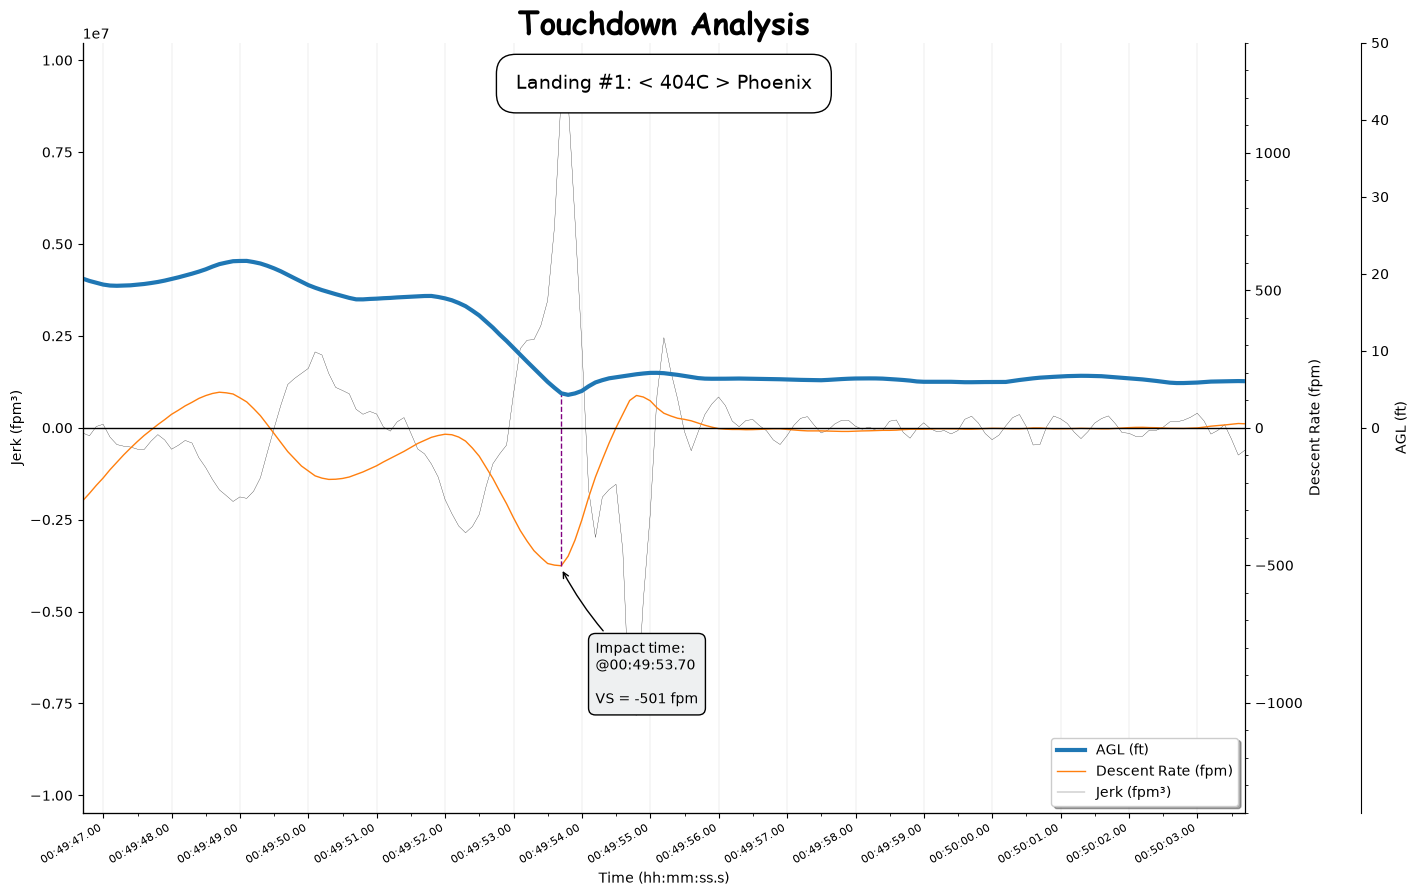

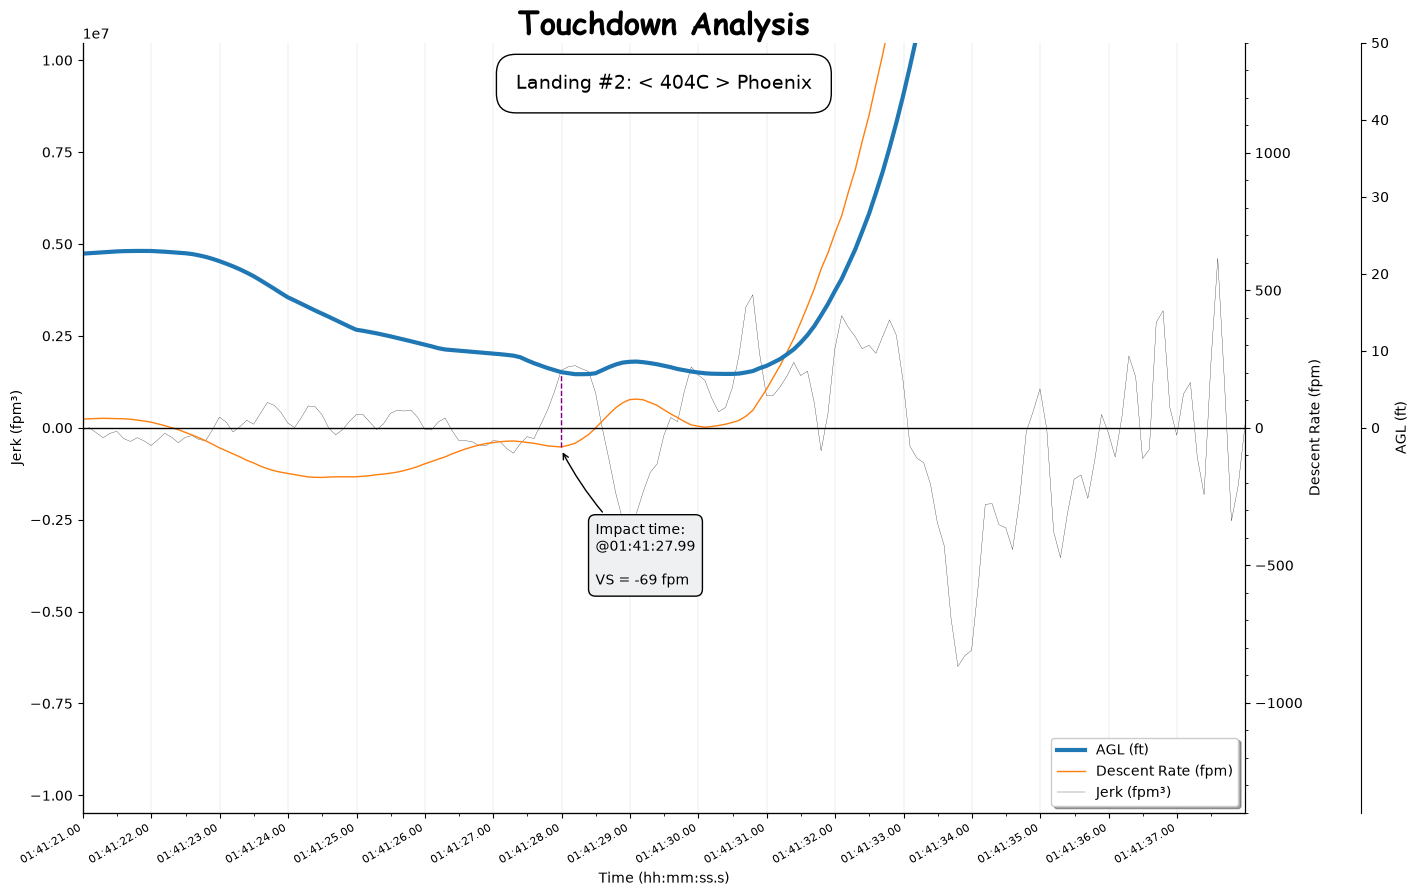

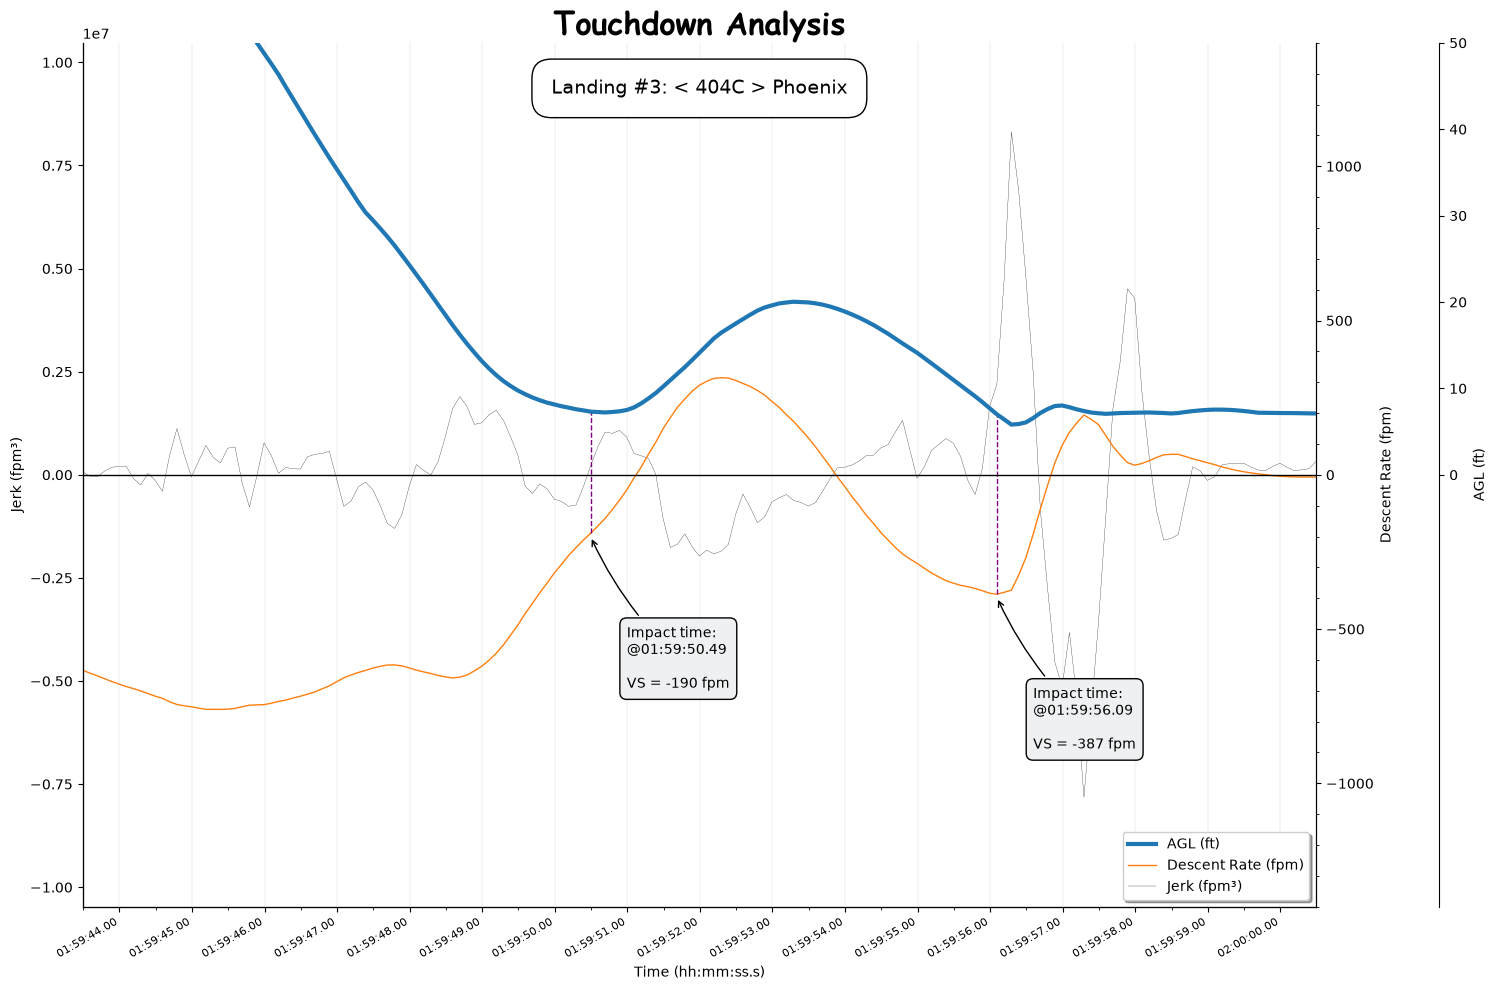

In [22]:
##################################################################
################### TOUCHDOWN PLOTTER FUNCTION ###################

def touchdown_plotter(pilot, sortie_num):

    # Break if current touchdown is less than 5 second the previous one
    current_touchdown  = df_result.loc[(df_result['Pilot'] == pilot) & (df_result['sortie_num'] == sortie_num    ), 'td_timestamp_seconds']
    previous_touchdown = df_result.loc[(df_result['Pilot'] == pilot) & (df_result['sortie_num'] == sortie_num - 1), 'td_timestamp_seconds']
    next_touchdown     = df_result.loc[(df_result['Pilot'] == pilot) & (df_result['sortie_num'] == sortie_num + 1), 'td_timestamp_seconds']
    
    # If there's no previous touchdown, we can't compare
    if not current_touchdown.empty and not previous_touchdown.empty:
        if current_touchdown.iloc[0] - previous_touchdown.iloc[0] < 10:
            print(f'Sortie #{sortie_num} of {pilot} Took less than 5 second!')
            return

    # Filter to Pilot
    df_plot = df_sub[df_sub['Pilot'] == pilot]

    # time_window & next touchdown
    touch_moment  = df_result[(df_result['Pilot'] == pilot) & (df_result['sortie_num'] == sortie_num)]   ['td_timestamp_seconds'].iloc[0]
    if df_result[(df_result['Pilot'] == pilot) & (df_result['sortie_num'] == sortie_num+1)] ['td_timestamp_seconds'].shape[0] > 0:
        touch_moment2 = df_result[(df_result['Pilot'] == pilot) & (df_result['sortie_num'] == sortie_num+1)] ['td_timestamp_seconds'].iloc[0]
    else:
        touch_moment2 = False

    time_window = (touch_moment-7, touch_moment+10)

    # Manual time_window
    # time_window = dt.timedelta(hours=3, minutes=26, seconds= 12).total_seconds(), dt.timedelta(hours=3, minutes=26, seconds= 20).total_seconds()

    #################### Jerk plot ##################

    fig, ax1= plt.subplots(figsize=(15, 10))

    sns.lineplot(data=df_plot, x='timestamp_seconds', y='vert_Jerk_fpm3', ax=ax1, 
                color='k', linewidth=0.2, label='Jerk (fpm³)')

    ax1_ylim = max(abs(ax1.get_ylim()[0]), abs(ax1.get_ylim()[1]))
    ax1.set_ylim(-ax1_ylim, ax1_ylim)

    # SPINE POSITION
    # offset_text = ax1.yaxis.get_offset_text()
    # offset_text.set_x(-0.20) # Adjust this value for perfect alignment
    # offset_text.set_horizontalalignment('left')

    # X-AXIS FORMATTING
    plt.xlim(time_window)

    ax1.xaxis.set_major_formatter(plt.FuncFormatter(format_seconds))
    major_locator = ticker.MultipleLocator(1)   # Major ticks every ? seconds
    minor_locator = ticker.MultipleLocator(0.5)  # Minor ticks every ? second
    ax1.xaxis.set_major_locator(major_locator)
    ax1.xaxis.set_minor_locator(minor_locator)

    for label in ax1.get_xticklabels():
        label.set(rotation=30, horizontalalignment='right', fontsize= 8)

    # Y-AXIS FORMATTING
    # plt.ylim(-0.8e5, 0.8e5)
    formatter = ticker.ScalarFormatter(useMathText=False)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-1, 1))
    ax1.yaxis.set_major_formatter(formatter)

    # #################### Vertical Acceleration plot ##################
    # ax2 = ax1.twinx()    
    # sns.lineplot(data=df_plot, x='timestamp_seconds', y='vert_Acc_fpm2', ax=ax2, 
    #             color='blue', linewidth=0.1, label='Vertical Acceleration (fpm²)')

    #################### Vertical Speed plot ##################
    ax2 = ax1.twinx()
    sns.lineplot(data=df_plot, x='timestamp_seconds', y='VS', ax=ax2, 
                color='tab:orange', linewidth=1, label='Descent Rate (fpm)')

    ax2.set_ylim(-1400, 1400)   
    ax2.set_yticks(np.arange(-1400, 1500, 100), minor=True)

    #################### AGL plot ##################
    ax3 = ax1.twinx()
    ax3.spines.right.set_position(("axes", 1.1))

    sns.lineplot(data=df_plot, x='timestamp_seconds', y='AGL', ax=ax3, 
                color='tab:blue', linewidth=3, label='AGL (ft)')

    ax3.set_ylim(-50, 50)
    ax3.set_yticks(np.arange(0, 51, 10), minor=False)

    ax3.axhline(y=0, color='k', linestyle='-', linewidth=1)

    # DESPINE
    ax1.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax3.spines['top'].set_visible(False)

    # GRIDLINES
    ax1.grid(axis='x', which='major', linestyle='-', linewidth='0.1', color='gray')
    # ax1.grid(axis='x', which='minor', linestyle=':', linewidth='0.5', color='gray')             
    # ax4.grid(axis='y', which='major', linestyle='-', linewidth='0.5', color='gray') 
    # ax4.grid(axis='y', which='minor', linestyle=':', linewidth='0.5', color='gray') 

    # TITLES
    plt.title(f'Touchdown Analysis', fontsize=22, fontweight='bold', family='cursive')
    
    ax1.text(np.mean(ax1.get_xlim())*1, ax1.get_ylim()[1]*0.9, 
            f'Landing #{sortie_num}: {df_plot["Pilot"].iloc[0]}', 
            fontsize=14, ha='center', va= 'center_baseline', color='k',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=1'))

    ax1.set_xlabel('Time (hh:mm:ss.s)')
    ax1.set_ylabel('Jerk (fpm³)')    
    ax2.set_ylabel('Descent Rate (fpm)')
    ax3.set_ylabel('AGL (ft)')
    # ax1.set_ylabel('Vertical Acc (fpm²)')

    # LEGENDS
    ax1.get_legend().remove()
    ax2.get_legend().remove()
    ax3.get_legend().remove()

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    
    ax1.legend(lines3 + lines2 + lines1, labels3 + labels2 + labels1, loc='lower right', shadow=True)

    # ANNOTATE THE IMPACT
    vs_1st  = df_plot[df_plot['timestamp_seconds'] == touch_moment]['VS'] .iloc[0]
    agl_1st = df_plot[df_plot['timestamp_seconds'] == touch_moment]['AGL'].iloc[0]
    ax2.axvline(x=touch_moment , color='purple', linestyle='--', linewidth=1, ymin= (1400+vs_1st)/2800, ymax= (50+agl_1st)/100)
    ax2.annotate(text= 'Impact time: \n@' + format_seconds(touch_moment) + f'\n\nVS = {int(vs_1st)} fpm',
                xy     = (touch_moment    , vs_1st - 10 ), 
                xytext = (touch_moment+0.5, vs_1st - 500),
                arrowprops=dict(facecolor='black', arrowstyle="->", connectionstyle="arc3, rad=-0.1"),
                bbox=dict(facecolor="#EEF0F1FF", edgecolor='black', boxstyle='round, pad=0.5')
                )
    if touch_moment2:
        vs_2nd  = df_plot[df_plot['timestamp_seconds'] == touch_moment2]['VS'] .iloc[0]
        agl_2nd = df_plot[df_plot['timestamp_seconds'] == touch_moment2]['AGL'].iloc[0]
        ax2.axvline (x=touch_moment2, color='purple', linestyle='--', linewidth=1, ymin= (1400+vs_2nd)/2800, ymax= (50+agl_2nd)/100)
        ax2.annotate(text= 'Impact time: \n@' + format_seconds(touch_moment2) + f'\n\nVS = {int(vs_2nd)} fpm',
                    xy    = (touch_moment2    , vs_2nd - 10 ), 
                    xytext= (touch_moment2+0.5, vs_2nd - 500),
                    arrowprops=dict(facecolor='black', arrowstyle="->", connectionstyle="arc3, rad=-0.1"),
                    bbox=dict(facecolor="#EEF0F1FF", edgecolor='black', boxstyle='round, pad=0.5')
                    )
    
    # EXPORT PLOTS
    # fig.savefig(os.path.join (results_dir+'\\Detailed Touchdowns', 
    #                         f'{date_tacview}_{replace_angles(pilot)}_touch_{sortie_num}.png'
    #                         ), 
    #             dpi=300, bbox_inches='tight'
    #             )


##################################################################
################### Creating subplots landings ###################
# touchdown_plotter(pilot= '< 404C > Phoenix', sortie_num= 4)
for pilot in ['< 404C > Phoenix']:
    for sortie in df_result[df_result['Pilot'] == pilot]['sortie_num'].unique():
        touchdown_plotter(pilot, sortie)

plt.style.use('default')
plt.tight_layout()
plt.show()